# Synthetic scRNA-seq Data Generator — Flat Design (No Correlated Modules)

**What this notebook is:** generates synthetic single-cell RNA-seq count data with a known ground truth (which genes are truly disease-relevant vs. background noise), for testing feature-selection methods. This is the **flat** variant: the 100 "signal" genes are one independent group with no internal correlation structure — see `correlated_syntheticData.ipynb` for the version with correlated gene modules, and `correlated_with_subtypes_syntheticdata.ipynb` for modules + patient subtype heterogeneity on top.

**Data-generating hierarchy:** patient → cell → gene. Each patient belongs to Group1 (diseased) or Group2 (healthy) and contributes multiple cells; each cell gets its own sequencing-depth ("size factor"); each gene's expression count in each cell is drawn from a Negative Binomial distribution whose mean depends on group, patient, and technical factors. Everything is seeded (`seed = 42`) for reproducibility.

## Table of contents
- [Step 1: Imports and random seed](#Step-1)
- [Step 2: Simulation parameters](#Step-2) — **start here if you want to change anything about the data**
- [Step 3: Patient metadata](#Step-3)
- [Step 4: Cell metadata (size factors)](#Step-4)
- [Step 5: Gene labeling (signal vs. background)](#Step-5)
- [Step 6: Patient random effects (`gamma_i`)](#Step-6)
- [Step 7: Group-specific means](#Step-7)
- [Step 8: Simulate gene expression counts](#Step-8) — the core generative step
- [Step 9: Reshape to gene x cell matrix](#Step-9)
- [Step 10: Per-gene summary statistics](#Step-10)
- [Step 11: Box plot — signal vs. background](#Step-11)

**This notebook ends at the fully-generated, validated dataset** (`counts_df`, `genes_df`, `patients_df`, `cells_df`). Baseline model testing (L1, STG, and others) is deliberately a separate concern — see the accompanying baseline-methods notebook, which is meant to `%run` this one first and then work from the in-memory data it leaves behind.

## Step 1: imports and random seed

Fixes reproducibility for everything that follows via the legacy global `np.random` state. **Run this notebook top-to-bottom once per session** — re-running an individual cell out of order re-consumes random draws from the same stream and desynchronizes downstream cells from what's shown here. If results ever look inconsistent with a previous run, the first thing to check is whether every cell was actually re-run in order from the top.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns


seed = 42
np.random.seed(seed)

print("Imported numpy, pandas, scipy.stats, matplotlib, seaborn")
print("Random seed set to", seed)

Imported numpy, pandas, scipy.stats, matplotlib, seaborn
Random seed set to 42


## Step 2: simulation parameters

Every knob that controls the simulated data lives here, in one place. **Change values here, not inline further down the notebook.**

**Quick tuning guide:**
- `fold_change` — how many times higher signal-gene expression is in Group1 (diseased) vs. Group2 (healthy). Higher = easier classification task.
- `dispersion` — Negative Binomial overdispersion. *Lower* value = *more* per-gene noise (counter-intuitive: this is an inverse-variance-style parameter, not a variance itself). Lower dispersion = harder task.
- `sigma2` — variance of the patient-level random effect (`gamma_i`, Step 6). Higher = more patient-to-patient noise, harder task.
- `size_factor_mean` / `size_factor_sd` — simulated sequencing depth per cell. Not really a "difficulty" knob, more a realism knob (real scRNA-seq has this kind of technical variability).
- `n_signal_genes` / `n_genes_total` — how many of the 1000 genes actually carry group signal (100 by default, the rest are pure background noise).

**Debugging tip:** if a downstream cell errors out with something like "p must be in (0, 1)" from `nbinom.rvs`/`nbinom.ppf` in Step 8, it almost always means a mean (`mu`) went to zero or negative — check whether `sigma2` was pushed large enough that `gamma_i` could swing a gene's mean below zero (see Step 6's note).

In [2]:
# Step 2: harder simulation parameters
#
n_patients_group1 = 10
n_patients_group2 = 10
cells_per_patient = 50
n_genes_total = 1000
n_signal_genes = 100

fold_change = 3
mu_background = 2
sigma2 = 0.20
dispersion = 15.0

size_factor_mean = 2000
size_factor_sd = 300

print("Simulation parameters defined")
print("Group 1 patients:", n_patients_group1)
print("Group 2 patients:", n_patients_group2)
print("Cells per patient:", cells_per_patient)
print("Total genes:", n_genes_total)
print("Signal genes:", n_signal_genes)
print("Fold change:", fold_change)

Simulation parameters defined
Group 1 patients: 10
Group 2 patients: 10
Cells per patient: 50
Total genes: 1000
Signal genes: 100
Fold change: 3


## Step 3: patient-level metadata

Assigns each of the 20 patients to Group1 (diseased, `n_patients_group1`) or Group2 (healthy, `n_patients_group2`).

In [3]:
# Step 3: create patient metadata

patient_ids = [f"P{i+1}" for i in range(n_patients_group1 + n_patients_group2)]
groups = (
    ["Group1"] * n_patients_group1 +
    ["Group2"] * n_patients_group2
)

patients_df = pd.DataFrame({
    "patient_id": patient_ids,
    "group": groups
})

patients_df

,patient_id,group
0,P1,Group1
1,P2,Group1
2,P3,Group1
3,P4,Group1
4,P5,Group1
5,P6,Group1
6,P7,Group1
7,P8,Group1
8,P9,Group1
9,P10,Group1


## Step 4: cell-level metadata

Each patient contributes `cells_per_patient` cells, and each cell gets its own `size_factor` — a technical sequencing-depth effect, not biology. This is the quantity that later needs to be normalized out before measuring "real" gene-gene correlation (not really an issue in this flat notebook since there's no module structure to measure, but see the correlated-data notebooks for where this matters).

In [4]:
# Step 4: create cell metadata with size factors

cell_rows = []

for _, row in patients_df.iterrows():
    patient_id = row["patient_id"]
    group = row["group"]

    size_factors = np.random.normal(loc=size_factor_mean, scale=size_factor_sd, size=cells_per_patient)
    size_factors = np.clip(size_factors, a_min=1, a_max=None)

    for cell_idx in range(cells_per_patient):
        cell_rows.append({
            "patient_id": patient_id,
            "group": group,
            "cell_id": f"{patient_id}_C{cell_idx+1}",
            "size_factor": size_factors[cell_idx]
        })

cells_df = pd.DataFrame(cell_rows)

cells_df.head()

,patient_id,group,cell_id,size_factor
0,P1,Group1,P1_C1,2149.014246
1,P1,Group1,P1_C2,1958.520710
2,P1,Group1,P1_C3,2194.306561
3,P1,Group1,P1_C4,2456.908957
4,P1,Group1,P1_C5,1929.753988


## Step 5: gene labeling

Splits the 1000 total genes into `n_signal_genes` (100, truly group-differential) and background (900, pure noise). In this flat design every signal gene is independent of every other — there's no gene grouping/module structure here (compare to `correlated_syntheticData.ipynb`'s `module_id` column).

In [5]:
# Step 5: label genes

gene_ids = [f"G{i+1}" for i in range(n_genes_total)]

signal_gene_ids = gene_ids[:n_signal_genes]
background_gene_ids = gene_ids[n_signal_genes:]

genes_df = pd.DataFrame({
    "gene_id": gene_ids,
    "gene_type": ["signal"] * n_signal_genes + ["background"] * (n_genes_total - n_signal_genes)
})

genes_df.head(10)

,gene_id,gene_type
0,G1,signal
1,G2,signal
2,G3,signal
3,G4,signal
4,G5,signal
5,G6,signal
6,G7,signal
7,G8,signal
8,G9,signal
9,G10,signal


## Step 6: patient random effects (`gamma_i`)

A per-patient intercept representing a genuine patient-level effect (e.g. overall transcriptional activity or technical batch) — every one of a patient's cells shares the same `gamma_i` draw. Step 8 applies it additively to every gene's mean, signal and background alike, since a real patient-level effect should shift all of that patient's expression together, not just the "interesting" genes.

**Debugging tip:** `gamma_i` is added directly to a gene's mean (not exponentiated), so a large enough `sigma2` combined with a small `mu_background` could in principle push a gene's mean to zero or below. Step 8 floors the mean just above zero as a safety net — if you push `sigma2` much higher than the default `0.20`, check the floor is actually catching cases, not silently distorting a lot of genes.

In [6]:
# Step 6: patient random effects

patient_effects = np.random.normal(
    loc=0,
    scale=np.sqrt(sigma2),
    size=len(patients_df)
)

patients_df["gamma_i"] = patient_effects

patients_df

,patient_id,group,gamma_i
0,P1,Group1,0.625811
1,P2,Group1,0.413509
2,P3,Group1,0.026668
3,P4,Group1,-0.289319
4,P5,Group1,0.312255
5,P6,Group1,0.175972
6,P7,Group1,0.400343
7,P8,Group1,0.284057
8,P9,Group1,0.469374
9,P10,Group1,-0.239364


## Step 7: group-specific means

Defines the four possible (group, gene-type) mean combinations: `mu_group1_signal` (boosted, `fold_change` applied), `mu_group2_signal` (baseline), and `mu_group1_background`/`mu_group2_background` (both equal to `mu_background` — background never differs by group).

In [7]:
# Step 7: define group-specific means

mu_group1_signal = mu_background * fold_change
mu_group2_signal = mu_background

mu_group1_background = mu_background
mu_group2_background = mu_background

print("mu_group1_signal =", mu_group1_signal)
print("mu_group2_signal =", mu_group2_signal)
print("mu_group1_background =", mu_group1_background)
print("mu_group2_background =", mu_group2_background)

mu_group1_signal = 6
mu_group2_signal = 2
mu_group1_background = 2
mu_group2_background = 2


## Step 8: simulate gene expression counts — the core generative step

For every (patient, cell, gene) combination, computes a Negative Binomial mean from `size_factor × (group/gene-type base mean + gamma_i)`, converts to the NB's `(n, p)` parameterization via `var = mu + mu²/dispersion`, and draws a count with `nbinom.rvs`.

**Debugging tips:**
- If you see a `ValueError` from `nbinom.rvs`, it's almost always an invalid `p` (must be in `(0, 1)`), which traces back to `mu <= 0` — see Step 6's note about `gamma_i` and `sigma2`.
- Runtime scales with `n_patients × cells_per_patient × n_genes_total` (one Python-level loop iteration per cell, one NB draw per gene) — this cell is the slowest one in the notebook. If you're only changing a baseline model's hyperparameters and not touching Step 2's data parameters, you don't need to re-run this cell (or the notebook above it) again this session.

In [8]:
# Step 8: simulate gene expression counts (cleaner NB parameterization)

from scipy.stats import nbinom

count_rows = []

for _, cell in cells_df.iterrows():
    patient_id = cell["patient_id"]
    group = cell["group"]
    cell_id = cell["cell_id"]
    size_factor = cell["size_factor"]
    gamma_i = patients_df.loc[patients_df["patient_id"] == patient_id, "gamma_i"].values[0]

    if group == "Group1":
        signal_mu_base = mu_group1_signal
        background_mu_base = mu_group1_background
    else:
        signal_mu_base = mu_group2_signal
        background_mu_base = mu_group2_background

    signal_mu = signal_mu_base + gamma_i
    background_mu = background_mu_base #can try to remove, easier if you remove if sigma
# make sure std dev is lesser than the mu (gamma i shouldnt be too big), can set mu to 2 and
# keep gamma i 0.4,
    for gene_id in signal_gene_ids:
        mu = size_factor * signal_mu
        var = mu + (mu**2) / dispersion #you can try increasing this because mu is 4000-16000
        p = mu / var
        n = mu * p / (1 - p)
        expr = nbinom.rvs(n, p)

        count_rows.append({
            "patient_id": patient_id,
            "group": group,
            "cell_id": cell_id,
            "gene_id": gene_id,
            "gene_type": "signal",
            "expression": expr
        })
# check for correlation with spearmann or pearson coefficient
    for gene_id in background_gene_ids:
        mu = size_factor * background_mu
        var = mu + (mu**2) / dispersion
        p = mu / var
        n = mu * p / (1 - p)
        expr = nbinom.rvs(n, p)

        count_rows.append({
            "patient_id": patient_id,
            "group": group,
            "cell_id": cell_id,
            "gene_id": gene_id,
            "gene_type": "background",
            "expression": expr
        })

counts_df = pd.DataFrame(count_rows)
counts_df.head()

,patient_id,group,cell_id,gene_id,gene_type,expression
0,P1,Group1,P1_C1,G1,signal,15910
1,P1,Group1,P1_C1,G2,signal,11835
2,P1,Group1,P1_C1,G3,signal,13085
3,P1,Group1,P1_C1,G4,signal,8653
4,P1,Group1,P1_C1,G5,signal,14836


## Step 9: reshape to a gene x cell matrix

Convenient wide-format view (`expression_matrix`) for eyeballing/plotting. The baseline-methods notebook builds a separate *cell x gene* matrix (the transposed orientation `sklearn` expects) from `counts_df` directly, so this cell isn't a dependency for modeling — it's a QC/visualization convenience.

In [9]:
# Step 9: reshape to gene x cell matrix

expression_matrix = counts_df.pivot_table(
    index="gene_id",
    columns="cell_id",
    values="expression",
    aggfunc="sum"
)
#new los min Loss contrastive (from Jessica's paper) + lambda sum of stochastic gate values
expression_matrix

cell_id,P10_C1,P10_C10,P10_C11,P10_C12,P10_C13,P10_C14,P10_C15,P10_C16,P10_C17,P10_C18,...,P9_C46,P9_C47,P9_C48,P9_C49,P9_C5,P9_C50,P9_C6,P9_C7,P9_C8,P9_C9
gene_id,,,,,,,,,,,,,,,,,,,,,
G1,10576,9389,14268,9935,11886,13101,7312,15352,12734,12337,...,11951,21034,17737,14090,11744,8157,17697,11221,11679,11182
G10,7639,12163,11622,11817,7217,11732,13667,11225,14766,11801,...,21905,17470,11741,11044,8407,11496,16326,13331,10524,16178
G100,18397,8559,13639,13012,8555,12140,9171,11434,12129,11825,...,15801,16402,11185,9188,15767,8686,14933,13564,12499,12531
G1000,4662,2202,5113,3338,2889,6199,4120,3143,3499,3338,...,6587,3404,2992,4897,5252,3602,2701,3631,4411,2460
G101,3961,3265,5296,4704,3649,4304,3028,4774,2375,2963,...,3487,3623,2565,6392,3672,4083,3427,3164,2148,5613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
G995,4063,2747,4768,3836,3700,7129,3794,3140,4018,4038,...,4462,4571,3385,4673,3462,1636,5216,2335,4514,2092
G996,4140,2579,4527,3993,4303,4764,5288,3720,3275,6711,...,3320,2228,3578,3970,3463,2625,6420,3298,2503,2532
G997,5553,4152,6480,4016,4609,2273,3358,2495,4845,5321,...,5019,3733,3481,2707,3245,2438,4599,2510,3005,4736


## Step 10: per-gene summary statistics

Mean/median/std/min/max per gene — a first numeric sanity check that signal genes look different from background before any modeling.

In [10]:
# Step 10: basic validation summaries

summary_by_gene = counts_df.groupby(["gene_id", "gene_type"])["expression"].agg(
    ["mean", "median", "std", "min", "max"]
).reset_index()

summary_by_gene.head(10)

,gene_id,gene_type,mean,median,std,min,max
0,G1,signal,8475.196,7314.5,4925.196862,1049,27412
1,G10,signal,8424.816,7147.0,5057.340776,1509,26351
2,G100,signal,8438.164,7229.5,5012.792426,1398,24486
3,G1000,background,3962.387,3814.5,1204.248127,1525,10302
4,G101,background,4015.663,3850.0,1230.895841,1437,8725
5,G102,background,4004.496,3910.5,1182.835590,1180,8582
6,G103,background,4005.719,3833.5,1251.099204,1289,8934
7,G104,background,3990.098,3850.5,1206.722666,1261,10335
8,G105,background,4020.980,3881.0,1194.177539,1444,9064
9,G106,background,4052.811,3903.0,1219.408869,1210,9934


## Step 11: visual sanity check — signal vs. background

Signal and background expression should be clearly separated in this box plot (signal genes: higher mean, wider spread from the `fold_change` boost; background: tighter, lower). If they look identical, double-check `fold_change`/`mu_background` in Step 2 before trusting anything downstream.

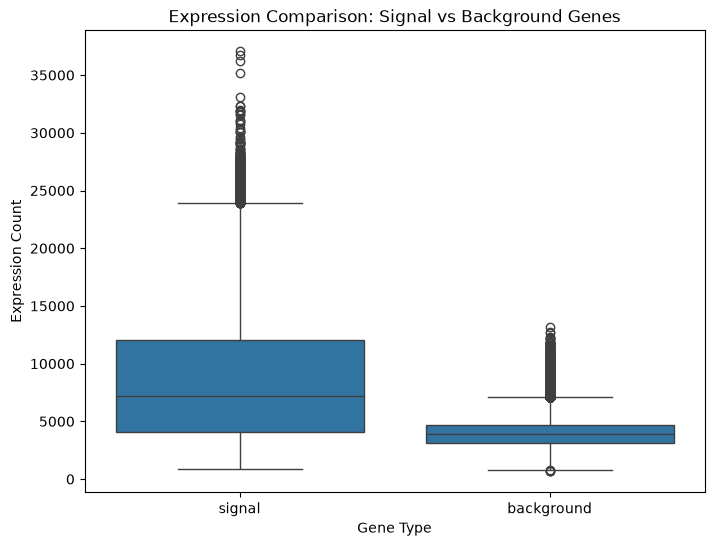

In [11]:
# Step 11: box plot for signal vs background gene expression

plot_df = counts_df.copy()

plt.figure(figsize=(8, 6))
sns.boxplot(data=plot_df, x="gene_type", y="expression")
plt.title("Expression Comparison: Signal vs Background Genes")
plt.xlabel("Gene Type")
plt.ylabel("Expression Count")
plt.show()

---
**Data generation complete.** `counts_df`, `genes_df`, `patients_df`, and `cells_df` are ready to be picked up by a baseline-methods notebook (`%run` this notebook first, or copy the relevant setup cells).